In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm

In [3]:
with open("data", "rb") as f:
    data = pickle.load(f)

In [4]:
DEVICE="cpu"

In [5]:
bad = data.get("bad").copy()
good = data.get("good").copy()

In [6]:
type(bad)

pandas.core.frame.DataFrame

In [5]:
index_chunks_b = np.split(np.arange(len(bad)),
                        # identified zeros
                        np.where(bad.index == 0)[0][1:])
index_chunks_g = np.split(np.arange(len(good)),
                        # identified zeros
                        np.where(good.index == 0)[0][1:])

In [6]:
def do(idx_bad, idx_good, extract_features):
    M = []
    for chunk in idx_bad:
        df = bad.iloc[chunk][['MS2.mz', 'MS2.intensity']].copy()
        observation = {"X" : df.to_numpy(), "Y" : np.zeros((1,1),dtype=np.int64)}
        observation["X"] = torch.from_numpy(observation["X"]).unsqueeze(0)
        observation["Y"] = torch.from_numpy(observation["Y"])                                    
        M.append(observation)
    for chunk in idx_good:
        df = good.iloc[chunk][['MS2.mz', 'MS2.intensity']].copy()
        observation = {"X" : df.to_numpy(), "Y" : np.ones((1,1),dtype=np.int64)}
        observation["X"] = torch.from_numpy(observation["X"]).unsqueeze(0)
        observation["Y"] = torch.from_numpy(observation["Y"])
        M.append(observation)
    if extract_features:
        np.random.shuffle(M)
        data_X = []
        for i in range(len(M)):
            centroid = M[i]["X"].mean(axis=1)
            dists = (((M[i]["X"][0] - centroid)**2).sum(1).sqrt())
            minimum = dists.min()
            maximum = dists.max()
            mean = dists.mean()
            std = dists.std()
            q50 = dists.quantile(.5)
            q25 = dists.quantile(.25)
            obs = torch.Tensor([minimum, maximum, mean, std, q50, q25]).unsqueeze(0)
            data_X.append(obs)
        data_X = torch.cat(data_X).to(DEVICE)
        data_Y = torch.Tensor([M[i]["Y"] for i in range(len(M))]).unsqueeze(-1).to(DEVICE)
        return data_X, data_Y
    else:
        return M
        

In [7]:
M = do(index_chunks_b, index_chunks_g, False)

In [8]:
train_x, train_y = do(index_chunks_b[:211], index_chunks_g[:211], True)
val_x, val_y = do(index_chunks_b[211:261], index_chunks_g[211:], True)

In [9]:
DEVICE="cpu"

In [10]:
class SvetaNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.do = nn.Dropout(0.5)
        self.bn1 = nn.BatchNorm1d(6)
        self.bn2 = nn.BatchNorm1d(32)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc1 = nn.Linear(6, 32)
        self.fc2 = nn.Linear(32, 64)
        self.fc3 = nn.Linear(64, 1)
        
    def total_params(self, requires_grad=True):
        pp=0
        for p in list(self.parameters()):
            if not p.requires_grad:
                continue
            nn=1
            for s in list(p.size()):
                nn = nn*s
            pp += nn
        return pp
    
    def forward(self, x):
        x = self.bn1(x)
        
        x = self.fc1(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.do(x)
        
        x = self.fc2(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.do(x)
        
        x = self.fc3(x)
        
        return x
    
class SvetaNetLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.do = nn.Dropout(0.66)
        self.bn1 = nn.BatchNorm1d(6)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc1 = nn.Linear(6, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 1)
        
    def total_params(self, requires_grad=True):
        pp=0
        for p in list(self.parameters()):
            if not p.requires_grad:
                continue
            nn=1
            for s in list(p.size()):
                nn = nn*s
            pp += nn
        return pp
    
    def forward(self, x):
        x = self.bn1(x)
        
        x = self.fc1(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.do(x)
        
        x = self.fc2(x)
        x = self.bn3(x)
        x = F.relu(x)
        #x = self.do(x)
        
        x = self.fc3(x)
        
        return x

In [11]:
net = SvetaNet()
optimizer = torch.optim.SGD(net.parameters(), lr=0.001, momentum=.9)
bce = torch.nn.BCEWithLogitsLoss()
batch_size = 8

In [12]:
net.total_params()

2605

In [ ]:
epochs = dict()
epochs_acc = dict()
epochs_val = dict()
epochs_acc_val = dict()
for epoch in tqdm(range(10_000)):
    epochs[epoch] = list()
    epochs_acc[epoch] = list()
    epochs_val[epoch] = list()
    epochs_acc_val[epoch] = list()
    idx = torch.randperm(train_x.shape[0])
    train_x = train_x[idx]
    train_y = train_y[idx]
    for i in range(0, len(train_x), batch_size):
        optimizer.zero_grad()
        X = train_x[i:i+batch_size].float()
        y = train_y[i:i+batch_size].float()
        yhat = net(X)
        #log_likelihood = (y * torch.log(yhat) + (1-y) * torch.log(1-yhat))
        #loss = -log_likelihood.mean()
        loss = bce(yhat,y)
        loss.backward()
        optimizer.step()
        preds = torch.where(yhat.detach().sigmoid() > .5, 1., 0.)
        acc = torch.where(preds == y.detach(), 1., 0.).mean()
        epochs[epoch].append(loss.item())
        epochs_acc[epoch].append(acc.item())
    for i in range(0, len(val_x), batch_size):
        with torch.no_grad():
            X = val_x[i:i+batch_size].float()
            y = val_y[i:i+batch_size].float()
            yhat = net(X)
            loss = bce(yhat,y)
            preds = torch.where(yhat.detach().sigmoid() > .5, 1., 0.)
            acc = torch.where(preds == y.detach(), 1., 0.).mean()
            epochs_val[epoch].append(loss.item())
            epochs_acc_val[epoch].append(acc.item())
            #print(list(f.modules())[1].weight.grad.sum())

 14%|█████▏                                | 1365/10000 [01:13<07:21, 19.55it/s]

/tmp/ipykernel_11785/3988741309.py:2: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  "val"   : [pd.Series(epochs_val[_]).mean() for _ in epochs_val]})
/tmp/ipykernel_11785/3988741309.py:4: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  "val"   : [pd.Series(epochs_acc_val[_]).mean() for _ in epochs_val]})


<AxesSubplot:>

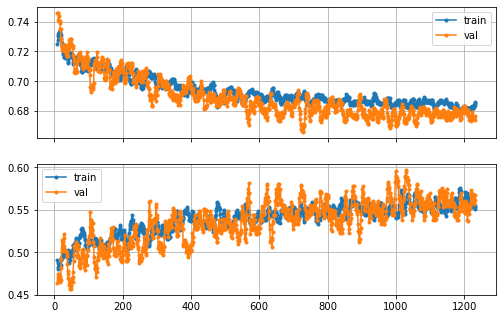

In [77]:
res_mean = pd.DataFrame({"train" : [pd.Series(epochs[_]).mean() for _ in epochs],
                         "val"   : [pd.Series(epochs_val[_]).mean() for _ in epochs_val]})
acc = pd.DataFrame({"train" : [pd.Series(epochs_acc[_]).mean() for _ in epochs],
                         "val"   : [pd.Series(epochs_acc_val[_]).mean() for _ in epochs_val]})
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8.24,5.3))
res_mean.rolling(10).mean().plot(grid=True, style=".-", ax=axes[0])
acc.rolling(10).mean().plot(grid=True, style=".-", ax=axes[1])

<AxesSubplot:>

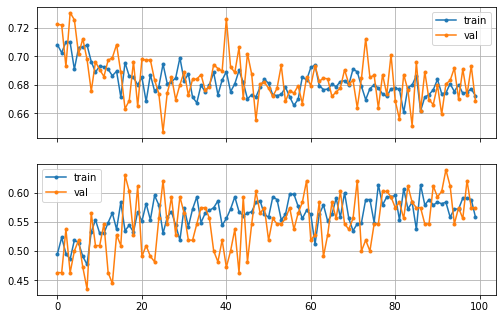

In [49]:
res_mean = pd.DataFrame({"train" : [pd.Series(epochs[_]).mean() for _ in epochs],
                         "val"   : [pd.Series(epochs_val[_]).mean() for _ in epochs_val]})
acc = pd.DataFrame({"train" : [pd.Series(epochs_acc[_]).mean() for _ in epochs],
                         "val"   : [pd.Series(epochs_acc_val[_]).mean() for _ in epochs_val]})
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8.24,5.3))
res_mean.plot(grid=True, style=".-", ax=axes[0])
acc.plot(grid=True, style=".-", ax=axes[1])

In [57]:
from sklearn.ensemble import RandomForestClassifier as RF

In [58]:
rf = RF()

In [59]:
fit = rf.fit(train_x, train_y.squeeze(1))

In [60]:
preds = torch.from_numpy(fit.predict(val_x)).unsqueeze(1)

In [66]:
val_acc = np.where(preds == val_y, 1, 0).mean()
val_acc

0.57

In [69]:
rf.feature_importances_

array([0.17386792, 0.16778114, 0.17351971, 0.17988461, 0.15918794,
       0.14575868])